In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
N = 16
L = 52.3
n_frames = 100
dx = L/N

In [4]:
avg_power_specrum = np.zeros((N,N))

for i in range(n_frames):

    noise = np.random.normal(0,1,(N,N))
    h_xy = noise

    h_q = np.fft.fft2(h_xy)

    power_spectrum = np.abs(h_q)**2

    avg_power_specrum += power_spectrum

avg_power_specrum = avg_power_specrum/n_frames


In [5]:
qx = np.fft.fftshift(np.fft.fftfreq(N,dx))
qy = np.fft.fftshift(np.fft.fftfreq(N,dx))

QX,QY = np.meshgrid(qx,qy)

Q_norm = np.sqrt(QX**2 + QY**2)

In [6]:
final_spectrum_2d = np.fft.fftshift(avg_power_specrum)/N**4


/tmp/ipykernel_19401/3410959894.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0,100))


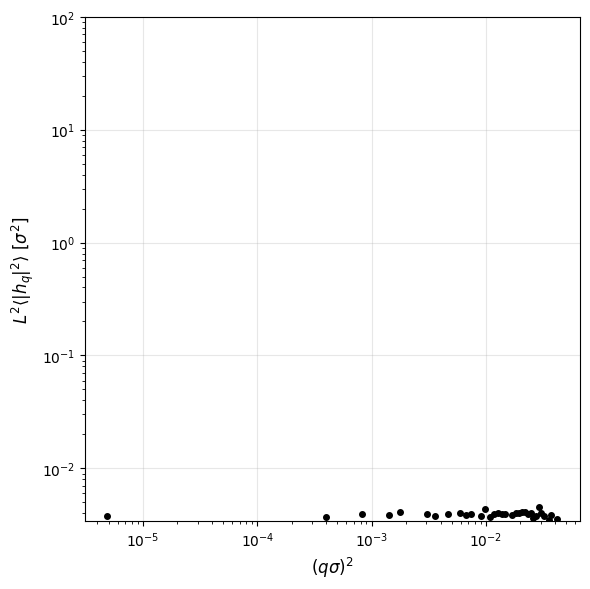

In [10]:
# ✅ Radiales Binning
def radial_profile(data, q_norm):
    """Berechnet radiales Mittel des 2D Power-Spektrums"""
    
    q_max = np.max(q_norm)
    q_bins = np.linspace(0, q_max, 50)
    q_centers = (q_bins[:-1] + q_bins[1:]) / 2
    
    radial_mean = []
    
    for i in range(len(q_bins)-1):
        mask = (q_norm >= q_bins[i]) & (q_norm < q_bins[i+1])
        values = data[mask]
        
        if len(values) > 0:
            radial_mean.append(np.mean(values))
        else:
            radial_mean.append(np.nan)
    
    return q_centers, np.array(radial_mean)

# ✅ Berechne radiales Profil
q_radial, power_radial = radial_profile(final_spectrum_2d, Q_norm)

# ✅ Einfacher Log-Log Plot
plt.figure(figsize=(6,6))

plt.loglog(q_radial**2, power_radial, 'o', color='black', markersize=4)

plt.xlabel(r'$(q\sigma)^2$', fontsize=12)
plt.ylabel(r'$L^2 \langle |h_q|^2 \rangle$ $[\sigma^2]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim((0,100))
plt.yscale("log")
plt.tight_layout()
plt.show()